In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your file
path = r'C:\Users\sumit\OneDrive\Desktop\Moving rating prediction\IMDb Movies India.csv'

# Try a robust encoding
df = pd.read_csv(path, encoding='latin1')   # works for most IMDb datasets

# If it still fails, use:
# df = pd.read_csv(path, encoding='ISO-8859-1')
# or
# df = pd.read_csv(path, encoding='windows-1252')

# Verify data loaded
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [2]:
# normalize column names
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# drop exact duplicates
df = df.drop_duplicates().reset_index(drop=True)

# trim whitespace for text columns
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip().replace({'nan': pd.NA})


In [32]:
# votes -> numeric (remove commas)
if 'votes' in df.columns:
    df['votes'] = df['votes'].astype(str).str.replace(',', '')
    df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# rating -> numeric
if 'rating' in df.columns:
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# duration -> runtime_mins (extract integer minutes)
if 'duration' in df.columns:
    df['runtime_mins'] = df['duration'].astype(str).str.extract(r'(\d+)', expand=False)
    df['runtime_mins'] = pd.to_numeric(df['runtime_mins'], errors='coerce')

# year -> numeric
if 'year' in df.columns:
    df['release_year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
per_year = df.groupby('Year').size().dropna()


In [4]:
if 'genre' in df.columns:
    df['genre_list'] = df['genre'].astype(str).str.split(',').apply(lambda lst: [g.strip() for g in lst] if isinstance(lst, list) else [])
    # To analyze per-genre counts:
    genres_exploded = df.explode('genre_list')


In [7]:
# Categorical: fill with 'Unknown'
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].fillna('Unknown')

# Numeric: fill with median
for c in df.select_dtypes(include=[np.number]).columns:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())


In [ ]:
print(df.shape)
print(df.isnull().sum())
df.to_csv( r'C:\Users\sumit\OneDrive\Desktop\Moving rating prediction\IMDb Movies India.csv', index=False)


(15509, 10)
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


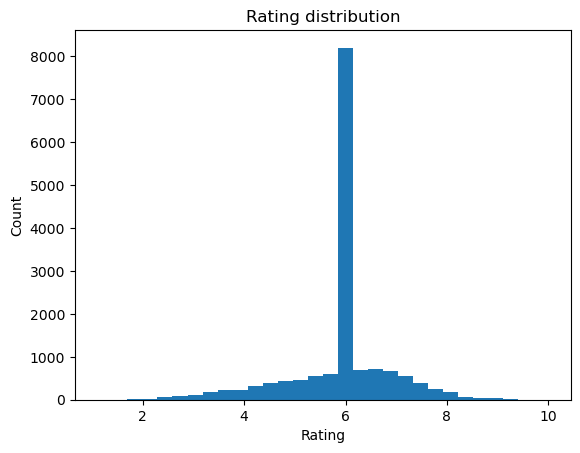

In [15]:
# 1. Rating histogram
plt.figure()
plt.hist(df['Rating'].dropna(), bins=30)
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

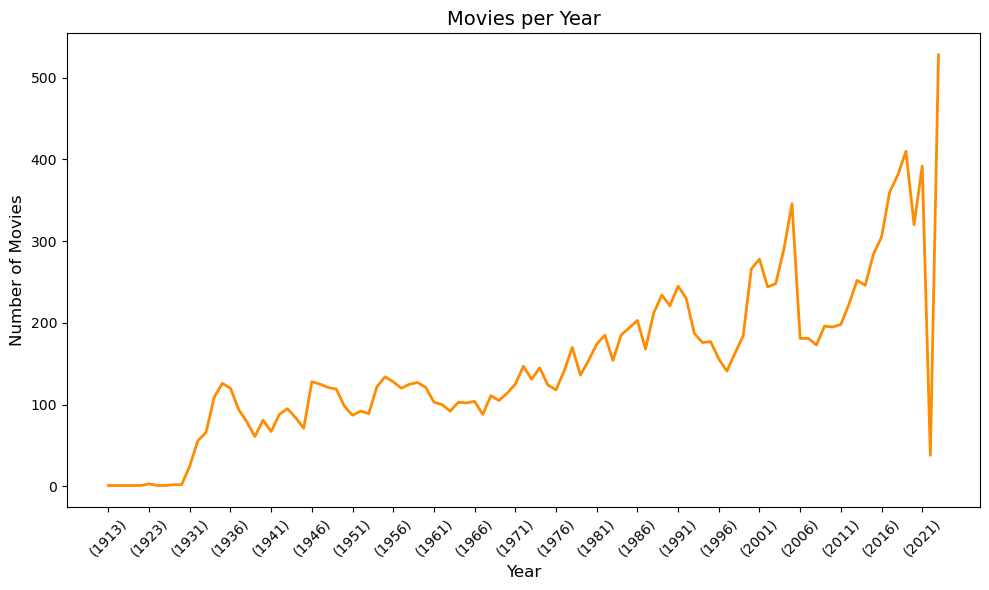

In [35]:
# 2. Movies per year
plt.figure(figsize=(10,6))
per_year = df.groupby('Year').size().dropna()
plt.plot(per_year.index, per_year.values, color='darkorange', linewidth=2)

plt.title('Movies per Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)

# show fewer x-ticks
plt.xticks(per_year.index[::5], rotation=45)  # every 5th year
plt.tight_layout()
plt.show()

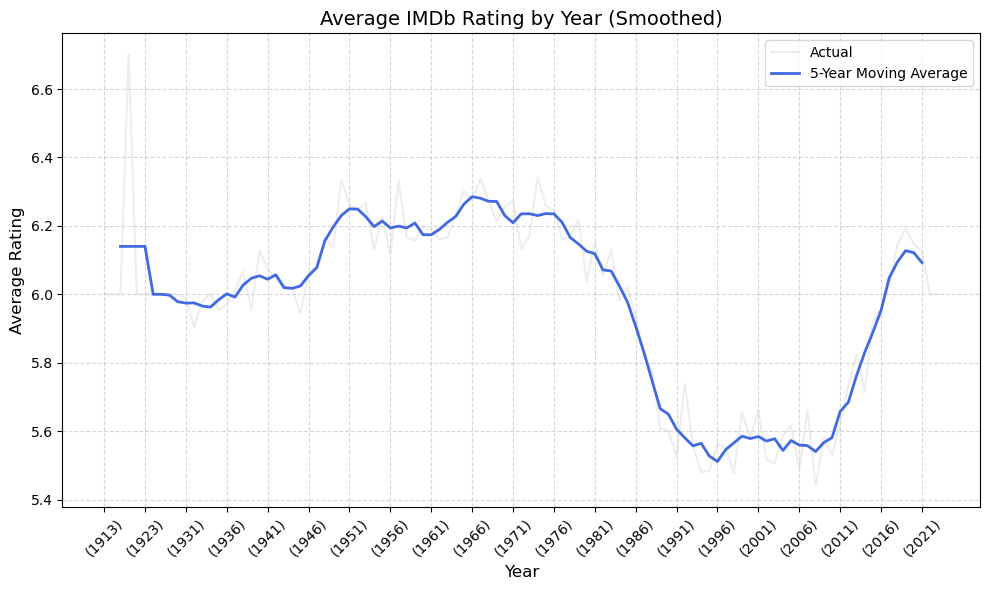

In [36]:
# 3. Average rating by year (with moving average)
avg_by_year_rolling = avg_by_year.rolling(window=5, center=True).mean()

plt.figure(figsize=(10,6))
plt.plot(avg_by_year.index, avg_by_year.values, alpha=0.4, label='Actual', color='lightgray')
plt.plot(avg_by_year.index, avg_by_year_rolling, color='royalblue', linewidth=2, label='5-Year Moving Average')

plt.title('Average IMDb Rating by Year (Smoothed)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.legend()
plt.xticks(avg_by_year.index[::5], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

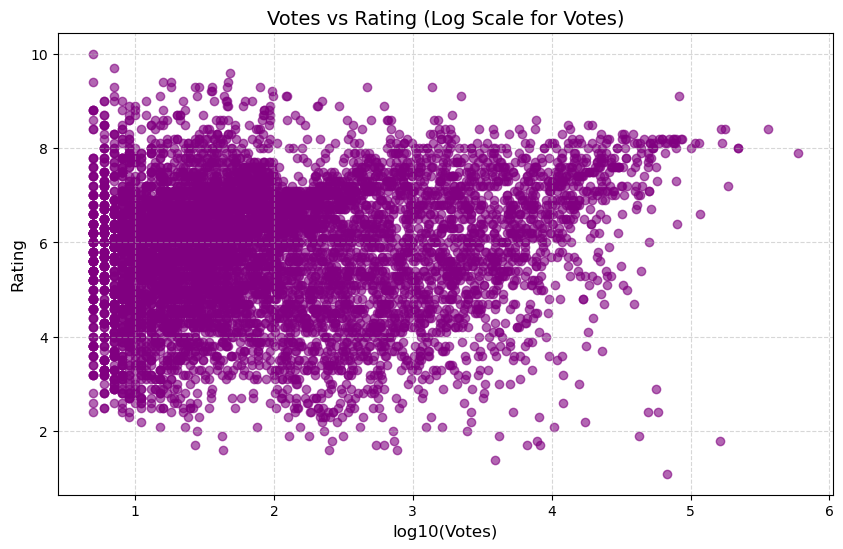

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Clean the 'Votes' column
df['Votes'] = df['Votes'].replace(',', '', regex=True)   # remove commas
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')  # convert to numbers (NaN if invalid)

# 2️⃣ Clean the 'Rating' column (just to be safe)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# 3️⃣ Drop rows where either is missing
df_clean = df.dropna(subset=['Votes', 'Rating'])

# 4️⃣ Create scatter plot with log scale
plt.figure(figsize=(10,6))
plt.scatter(np.log10(df_clean['Votes']), df_clean['Rating'], alpha=0.6, color='purple')
plt.title('Votes vs Rating (Log Scale for Votes)', fontsize=14)
plt.xlabel('log10(Votes)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

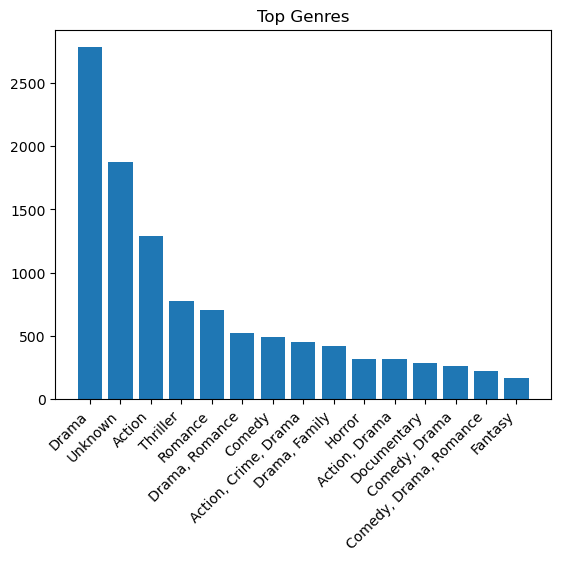

In [25]:
# 5. Top genres bar chart (requires exploded genres)
genres_exploded = df.explode('Genre')
top_genres = genres_exploded['Genre'].value_counts().head(15)
plt.figure()
plt.bar(top_genres.index, top_genres.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top Genres')
plt.show()

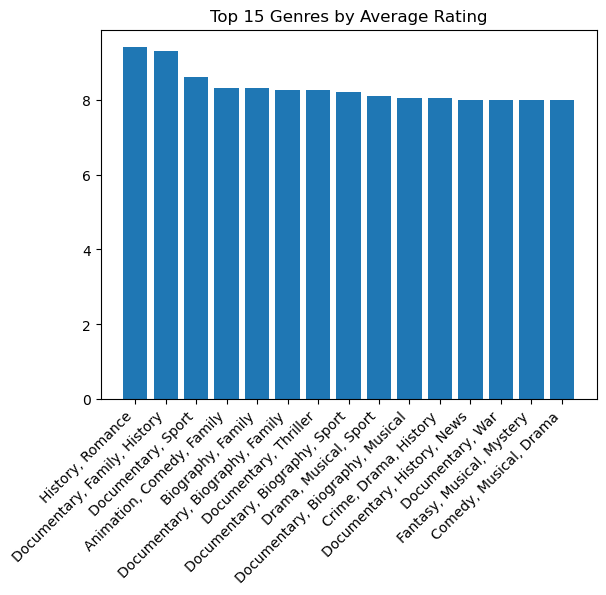

In [26]:
# 6. Average rating by genre (bar)
avg_genre = genres_exploded.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(15)
plt.figure()
plt.bar(avg_genre.index, avg_genre.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Genres by Average Rating')
plt.show()